In [1]:
from pydantic import BaseModel
from langgraph.graph import START, END, StateGraph

In [6]:
class BotState(BaseModel):
    name: str =""
    messages: list[str] = []

def GreetNode(state:BotState):
    state.messages = f"Hello ! Good morning {state.name}."
    return state

In [7]:
builder= StateGraph(BotState)

builder.add_node("greet", GreetNode)
builder.add_edge(START, "greet")
builder.add_edge("greet", END)
graph = builder.compile()

In [8]:
res = graph.invoke({"name":"Anurag"})

In [9]:
res

{'name': 'Anurag', 'messages': 'Hello ! Good morning Anurag.'}

#### Build simple QNA Chatbot

In [24]:
from pydantic import BaseModel
from typing import Annotated
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage

llm= ChatOpenAI(model= "gpt-4.1")

In [28]:
class ChatState(BaseModel):
    messages : Annotated[list, add_messages] = []

builder = StateGraph(ChatState)

In [29]:
def chat_node(state:ChatState) -> ChatState:
    res = llm.invoke(state.messages)
    state.messages = [{"role": "ai", "content": res.content}]
    return state



def to_upper_node(state: ChatState):
    last_msg = state.messages[-1]

    state.messages[-1] = AIMessage(
        content=last_msg.content.upper()
    )

    return state

builder.add_node("chat", chat_node)
builder.add_node("to_upper",to_upper_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", "to_upper")
builder.add_edge("to_upper", END)
graph = builder.compile()

In [30]:
res= graph.invoke({"messages": [{"role":"system", "content":"You are a helpful assistant."}, {"role":"user", "content":"What is the capital of France?"}]})

In [31]:
res

{'messages': [SystemMessage(content='You are a helpful assistant.', additional_kwargs={}, response_metadata={}, id='0cabca9d-3953-4960-a4e8-6a186fcac6dc'),
  HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='01954a90-5a56-4777-b8e7-ab53058a010b'),
  AIMessage(content='The capital of France is Paris.', additional_kwargs={}, response_metadata={}, id='cacb08f8-3be8-49a0-ba17-a7b514f68c21', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='THE CAPITAL OF FRANCE IS PARIS.', additional_kwargs={}, response_metadata={}, id='54954377-373c-4b64-8e3c-74d6bf50eb56', tool_calls=[], invalid_tool_calls=[])]}

In [32]:
from pydantic import BaseModel
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from typing import Literal

In [33]:
class GeneralState(BaseModel):
    question: str = ""
    category : str= ""
    answer: str = ""

In [34]:
def coding_agent(state:GeneralState) -> GeneralState:
    print("Coding Agent Called..")
    return state

def weather_agent(state:GeneralState) -> GeneralState:
    print("Weather Agent Called..")
    return state

def history_agent(state:GeneralState) -> GeneralState:
    print("History Agent Called..")
    return state


def classify_node(state:GeneralState) -> GeneralState:
    #### You can pass this question to llm, and ask the category
    #### ["code", "program", "python", "bug", "function"] ["weather", "temp", "rain"], [history]
    que = state.question.lower()
    if any(w in que for w in ["code", "program", "python", "bug", "function"]):
        state.category = "coding"
    elif any(w in que for w in ["weather", "temp", "rain"]):
        state.category = "weather"        
    else:
        state.category = "history"
    
    print(state.category)
    return state
    
#### ! node = conditional edgs
def route(state:GeneralState) -> Literal["coding_agent", "weather_agent", "history_agent"]:
    return f"{state.category}_agent"
    
graph = StateGraph(GeneralState)
graph.add_node("classify", classify_node)
graph.add_node("coding_agent", coding_agent)
graph.add_node("weather_agent", weather_agent)
graph.add_node("history_agent", history_agent)

graph.add_edge(START, "classify")
graph.add_conditional_edges("classify", route)

graph.add_edge("coding_agent", END)
graph.add_edge("weather_agent", END)
graph.add_edge("history_agent", END)

final_graph = graph.compile()

In [35]:
res = final_graph.invoke({"question": "Who is pm "})

history
History Agent Called..


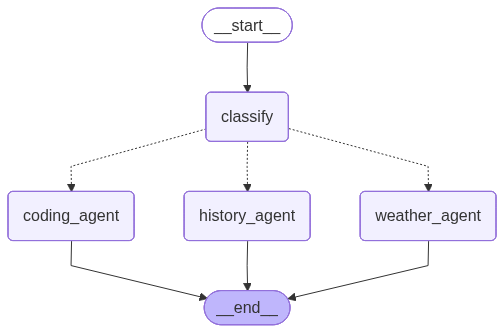

In [36]:
from IPython.display import Image
Image(final_graph.get_graph().draw_mermaid_png())

#### Checkpointer-Memory

In [39]:
from pydantic import BaseModel
from typing import Annotated
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage
from langgraph.checkpoint.memory import InMemorySaver

llm= ChatOpenAI(model= "gpt-4.1")

class ChatState(BaseModel):
    messages : Annotated[list, add_messages]

builder = StateGraph(ChatState)

def chat_node(state:ChatState) -> ChatState:
    res = llm.invoke(state.messages)
    state.messages = [{"role": "ai", "content": res.content}]
    return state

builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)
graph = builder.compile(checkpointer=InMemorySaver())

In [43]:
res = graph.invoke(
    {"messages": [{"role":"user", "content":"What is the capital of India?"}]},
    {"configurable":{"thread_id":"1"}}
)

In [44]:
res

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='f7d8dd15-bee5-4db6-9078-d5b5d0a51bc5'),
  AIMessage(content='The capital of France is **Paris**.', additional_kwargs={}, response_metadata={}, id='4a59ae0c-dbb6-43e6-a0f3-8e6cf3775f2c', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='4cf63e2a-207b-4b14-8a8d-2edded5bd867'),
  AIMessage(content='The capital of India is **New Delhi**.', additional_kwargs={}, response_metadata={}, id='80a96964-97a5-45e7-bc0c-fc88eb57e7aa', tool_calls=[], invalid_tool_calls=[])]}

# Order Management Agent using LangGraph

- **Order Details** – returns status and other fields
- **Cancel Order** – cancels only if `is_cancelable` is `True`
- **Return Order** – allowed only if status is `Delivered`; sets status to `Pickup Scheduled`

In [47]:
from typing import Literal, Optional
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
import re

In [46]:
data = {
    "ODR-01": {"status": "Placed",    "is_cancelable": False, "amount": 2300},
    "ODR-02": {"status": "Shipped",   "is_cancelable": True,  "amount": 12300},
    "ODR-03": {"status": "Delivered", "is_cancelable": False, "amount": 3300},
}

In [48]:
class OrderState(BaseModel):
    user_request: str                  # raw request text
    order_id: Optional[str] = None     # extracted order id
    intent: Optional[str] = None       # details | cancel | return | unknown
    response: Optional[str] = None     # final message to the user

In [49]:
def classify(state: OrderState) -> dict:
    text = state.user_request.lower()

    match = re.search(r"odr-\d+", text, re.IGNORECASE)
    order_id = match.group(0).upper() if match else None

    if "cancel" in text:
        intent = "cancel"
    elif any(w in text for w in ["return", "refund", "pickup"]):
        intent = "return"
    elif any(w in text for w in ["detail", "status", "info", "where", "track"]):
        intent = "details"
    else:
        intent = "unknown"

    return {"order_id": order_id, "intent": intent}

In [50]:
def order_details(state: OrderState) -> dict:
    oid = state.order_id
    order = data.get(oid)
    msg = (f"Order {oid} details:\n"
           f"  - Status: {order['status']}\n"
           f"  - Cancelable: {order['is_cancelable']}\n"
           f"  - Amount: {order['amount']}")
    return {"response": msg}


def cancel_order(state: OrderState) -> dict:
    oid = state.order_id
    order = data.get(oid)
    if order["is_cancelable"]:
        order["status"] = "Cancelled"
        msg = f"Order {oid} has been cancelled."
    else:
        msg = f"Order {oid} cannot be cancelled (current status: {order['status']})."
    return {"response": msg}


def return_order(state: OrderState) -> dict:
    oid = state.order_id
    order = data.get(oid)
    if order["status"] == "Delivered":
        order["status"] = "Pickup Scheduled"
        msg = f"Return accepted for {oid}. Status updated to 'Pickup Scheduled'."
    else:
        msg = (f"Order {oid} cannot be returned yet "
               f"(status: {order['status']}, must be 'Delivered').")
    return {"response": msg}


def invalid_order(state: OrderState) -> dict:
    return {"response": f"Order '{state.order_id}' was not found."}


def unknown_intent(state: OrderState) -> dict:
    return {"response": "Sorry, I can only fetch order details, cancel, or return an order."}

In [51]:
def route(state: OrderState) -> Literal["details", "cancel", "return", "invalid", "unknown"]:
    if state.intent == "unknown":
        return "unknown"
    if state.order_id not in data:
        return "invalid"
    return state.intent

In [53]:
builder = StateGraph(OrderState)

builder.add_node("classify", classify)
builder.add_node("details", order_details)
builder.add_node("cancel", cancel_order)
builder.add_node("return", return_order)
builder.add_node("invalid", invalid_order)
builder.add_node("unknown", unknown_intent)

builder.add_edge(START, "classify")

builder.add_conditional_edges(
    "classify",
    route,
    {
        "details": "details",
        "cancel": "cancel",
        "return": "return",
        "invalid": "invalid",
        "unknown": "unknown",
    },
)

for node in ["details", "cancel", "return", "invalid", "unknown"]:
    builder.add_edge(node, END)

graph = builder.compile()

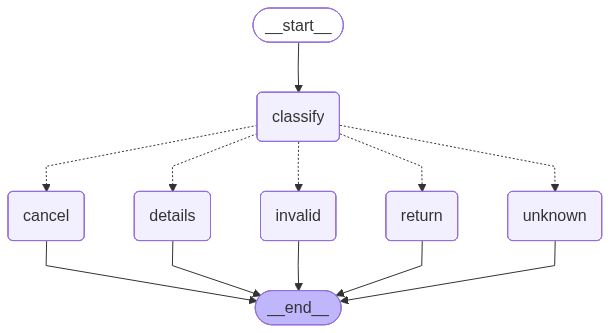

In [54]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

In [55]:
def run(request: str):
    result = graph.invoke(OrderState(user_request=request))
    print(f"USER: {request}")
    print(result["response"])
    print("-" * 60)

run("What are the details of ODR-01?")
run("Cancel my order ODR-02")
run("I want to cancel ODR-01")
run("Return order ODR-03")
run("Return ODR-02")
run("Where is ODR-99?")
run("Tell me a joke")

USER: What are the details of ODR-01?
Order ODR-01 details:
  - Status: Placed
  - Cancelable: False
  - Amount: 2300
------------------------------------------------------------
USER: Cancel my order ODR-02
Order ODR-02 has been cancelled.
------------------------------------------------------------
USER: I want to cancel ODR-01
Order ODR-01 cannot be cancelled (current status: Placed).
------------------------------------------------------------
USER: Return order ODR-03
Return accepted for ODR-03. Status updated to 'Pickup Scheduled'.
------------------------------------------------------------
USER: Return ODR-02
Order ODR-02 cannot be returned yet (status: Cancelled, must be 'Delivered').
------------------------------------------------------------
USER: Where is ODR-99?
Order 'ODR-99' was not found.
------------------------------------------------------------
USER: Tell me a joke
Sorry, I can only fetch order details, cancel, or return an order.
----------------------------------

In [56]:
for oid, o in data.items():
    print(oid, "->", o["status"])

ODR-01 -> Placed
ODR-02 -> Cancelled
ODR-03 -> Pickup Scheduled


In [60]:
pip install langgraph-checkpoint-sqlite

  Using cached aiosqlite-0.22.1-py3-none-any.whl.metadata (4.3 kB)
Using cached aiosqlite-0.22.1-py3-none-any.whl (17 kB)

   ------------- -------------------------- 1/3 [aiosqlite]
   -------------------------- ------------- 2/3 [langgraph-checkpoint-sqlite]
   ---------------------------------------- 3/3 [langgraph-checkpoint-sqlite]

Note: you may need to restart the kernel to use updated packages.


In [68]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

connection= sqlite3.connect("db.sqlite3", check_same_thread=False)
memory = SqliteSaver(conn=connection)
memory.setup()

In [69]:
from pydantic import BaseModel
from typing import Annotated
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage
from langgraph.checkpoint.memory import InMemorySaver

llm= ChatOpenAI(model= "gpt-4.1")

class ChatState(BaseModel):
    messages : Annotated[list, add_messages]

builder = StateGraph(ChatState)

def chat_node(state:ChatState) -> ChatState:
    res = llm.invoke(state.messages)
    state.messages = [{"role": "ai", "content": res.content}]
    return state

builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)
graph = builder.compile(checkpointer=memory)

In [70]:
res = graph.invoke(
    {"messages": [{"role":"user", "content":"What is the capital of India?"}]},
    {"configurable":{"thread_id":"1"}}
)

In [71]:
res

{'messages': [HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='00ac4343-7f98-4e68-82a0-e1ece8390e9f'),
  AIMessage(content='The capital of India is **New Delhi**.', additional_kwargs={}, response_metadata={}, id='31f3af49-d7b8-4d44-b93f-8f347f6aed11', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='dc8379f5-22ba-434f-b9a0-90087a0c1069'),
  AIMessage(content='The capital of India is **New Delhi**.', additional_kwargs={}, response_metadata={}, id='084aeb90-9aff-4d54-8b26-2cda7cf9f5a2', tool_calls=[], invalid_tool_calls=[])]}